### AUC_ROC
### Decision Tree

#### Decision Trees 
Decision Trees are classification models that split data into nodes based on feature values. To determine the best split, they rely on impurity metrics that evaluate how mixed a node’s class distribution is. Gini Impurity and Entropy are two measures used in decision trees to decide how to split data into branches. Both help determine how mixed or pure a dataset is, guiding the model toward splits that create cleaner groups.

#### Decision tree 
A decision tree works by asking a sequence of questions, and each split tries to increase certainity about the class label

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mushroom_data.csv', delimiter= ";")
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [85]:
import warnings
warnings.filterwarnings('ignore')

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [87]:
threshold =  len(df)*.95

df_cleaned =  df.dropna(thresh=threshold, axis=1)

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-color             61069 non-null  object 
 4   does-bruise-or-bleed  61069 non-null  object 
 5   gill-color            61069 non-null  object 
 6   stem-height           61069 non-null  float64
 7   stem-width            61069 non-null  float64
 8   stem-color            61069 non-null  object 
 9   has-ring              61069 non-null  object 
 10  ring-type             58598 non-null  object 
 11  habitat               61069 non-null  object 
 12  season                61069 non-null  object 
dtypes: float64(3), object(10)
memory usage: 6.1+ MB


In [88]:
df_cleaned['ring-type'].value_counts()

ring-type
f    48361
e     2435
z     2118
l     1427
r     1399
p     1265
g     1240
m      353
Name: count, dtype: int64

In [89]:
### fill in the missing values for this column using the categorical mode

# get the mode of the class
df_cleaned['ring-type'].mode()

0    f
Name: ring-type, dtype: object

In [90]:
# Get the mode value (first one if multiple modes exist)
filler = df_cleaned['ring-type'].mode()      # mode() returns a Series; [0] selects the first value so fillna gets a scalar

# Fill nulls with the mode
df_cleaned['ring-type'] = df_cleaned['ring-type'].fillna(filler[0])     # add [0] to the filler or the mode()[0] so that the series will the first expected datatype

# Check if any nulls remain
df_cleaned['ring-type'].isna().sum()



0

In [91]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-color             61069 non-null  object 
 4   does-bruise-or-bleed  61069 non-null  object 
 5   gill-color            61069 non-null  object 
 6   stem-height           61069 non-null  float64
 7   stem-width            61069 non-null  float64
 8   stem-color            61069 non-null  object 
 9   has-ring              61069 non-null  object 
 10  ring-type             61069 non-null  object 
 11  habitat               61069 non-null  object 
 12  season                61069 non-null  object 
dtypes: float64(3), object(10)
memory usage: 6.1+ MB


In [92]:
df_cleaned.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-color',
       'does-bruise-or-bleed', 'gill-color', 'stem-height', 'stem-width',
       'stem-color', 'has-ring', 'ring-type', 'habitat', 'season'],
      dtype='object')

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

#use for loop to encode our categorical to numeric
for col in df_cleaned.columns:
  df_cleaned[col] = encoder.fit_transform(df_cleaned[col])

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   class                 61069 non-null  int32
 1   cap-diameter          61069 non-null  int64
 2   cap-shape             61069 non-null  int32
 3   cap-color             61069 non-null  int32
 4   does-bruise-or-bleed  61069 non-null  int32
 5   gill-color            61069 non-null  int32
 6   stem-height           61069 non-null  int64
 7   stem-width            61069 non-null  int64
 8   stem-color            61069 non-null  int32
 9   has-ring              61069 non-null  int32
 10  ring-type             61069 non-null  int32
 11  habitat               61069 non-null  int32
 12  season                61069 non-null  int32
dtypes: int32(10), int64(3)
memory usage: 3.7 MB


In [94]:
# independent and dependent variables

X = df_cleaned.drop(['class'], axis=1)
y = df_cleaned['class']

X_train, X_test, y_train, y_test =  train_test_split(X, y, random_state=254, test_size=0.7)

In [95]:
#instantiate

dt = DecisionTreeClassifier(random_state=254)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=254)

In [96]:
from sklearn.metrics import accuracy_score, roc_curve , RocCurveDisplay, auc

#predictions

y_preds = dt.predict(X_test)

accuracy_score(y_test, y_preds)

0.9760696156635243

In [97]:
from sklearn.linear_model import LogisticRegression

#instantiate
lr = LogisticRegression()

lr.fit(X_train, y_train)



LogisticRegression()

In [98]:
# predictions in lr

lr_y_preds = lr.predict(X_test)

accuracy_score(y_test, lr_y_preds)

0.5856979110622471

In [99]:
dt.predict_proba(X_test)[:, 1]

array([0., 0., 0., ..., 1., 1., 0.])

In [100]:
# #probability for the linear regression model
lr_y_prob = lr.predict_proba(X_test)[:, 1]

dt_y_prob =  dt.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, i = roc_curve(y_test, lr_y_prob)

dt_fpr, dt_tpr, i = roc_curve(y_test, dt_y_prob)

lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)


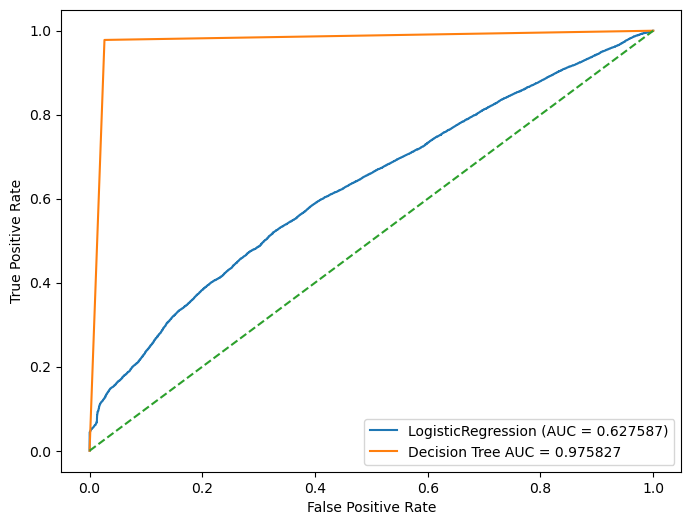

In [101]:
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'LogisticRegression (AUC = {lr_auc:2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree AUC = {dt_auc:2f}')
plt.plot([0,1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## HyperParameter tuning
- Hyperparameter tuning simply means finding the best settings for the knobs you can turn before training a machine learning model.


#### Next Phase

Hyperparameter tuning

GridSearch

CART Trees ( Classification and regression Trees)

In [102]:
tree =  DecisionTreeClassifier()